<a href="https://colab.research.google.com/github/anastasialbedeva/cs102-2024/blob/master/labs/%D0%9B%D0%A03_%D0%9E%D0%B1%D0%B5%D1%81%D0%BF%D0%B5%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [6]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns

В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [7]:
df = pd.read_csv('monster_com_job_sample.csv', encoding='utf-8', engine='python')
df.shape
df.sample(10)

,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
17824,United States of America,US,NaN,No,jobs.monster.com,POSITION PURPOSE:This position delivers ice to...,Local Route Driver CDL A & B Job in Dallas,Full Time,"Dallas, TX 75201",All,http://jobview.monster.com/Local-Route-Driver-...,NaN,Experienced (Non-Manager),05e3580ff0c2b557f566fe0c95fb4ced
8661,United States of America,US,NaN,No,jobs.monster.com,"GENERAL MANAGER, SERVICE MANAGER & KITCHEN MAN...",Restaurant Manager Job in Dallas,Full Time,"Dallas, TX",Restaurant/Food Services,http://jobview.monster.com/restaurant-manager-...,"50,000.00 - 70,000.00 $ /year",Manager (Manager/Supervisor of Staff),22aab2e4f35dd68dd1c868878eea7728
18643,United States of America,US,NaN,No,jobs.monster.com,Coordinator of Infection Prevention & Control ...,Coordinator of Infection Prevention & Control ...,"Part Time, Employee","Cincinnati, OH 45213",NaN,http://jobview.monster.com/Coordinator-of-Infe...,NaN,NaN,92292de6f3c1d2b132313526c579f26d
15137,United States of America,US,NaN,No,jobs.monster.com,MAC Management is of of the leading marketing ...,Campaign and Promotions Coordinator - Entry Le...,Full Time Employee,"Greenville, SC 29615",RetailAdvertising and PR ServicesBusiness Serv...,http://jobview.monster.com/campaign-promotions...,NaN,Project/Program Management,69acf6f2130a477733328ec5354f96de
14451,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job Congregation Bus...,Monster,"Full Time, Employee",Phone 3177832000 Address 6111 SHELBY STINDIANA...,Nonprofit Charitable Organizations,http://jobview.monster.com/business-manager-jo...,NaN,NaN,2eaa24279f378a4f1446a316f031a8ff
6466,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job Construction Man...,Matrix Technologies,Full Time,Construction ManagerProject Management Divisio...,Engineering Services,http://jobview.monster.com/construction-manage...,NaN,NaN,3fbfd7604b6e5f752b705845af691844
2874,United States of America,US,NaN,No,jobs.monster.com,"Fast-paced, family dental practice is looking ...",Dental Assistant and Dental Receptionist Job i...,Full Time,"Mountain Top, PA 18707",Healthcare Services,http://jobview.local-jobs.monster.com/Dental-A...,NaN,NaN,1654215b2a5890a6bda395ce439fb1f7
9101,United States of America,US,NaN,No,jobs.monster.com,Description:We are proud to be working with on...,Heavy Equipment Mechanic Job in Leoti,Full Time Employee,"Leoti, KS",Other/Not Classified,http://jobview.monster.com/Heavy-Equipment-Mec...,NaN,NaN,fea527e8da8d2495cf2063ec75df488e
3657,United States of America,US,NaN,No,jobs.monster.com,CHRISTUS HomeCare of Lake Charles is looking f...,Speech Language Pathologist PRN HH Job in Lake...,"Full Time, Employee","Lake Charles, LA 70605",Healthcare Services,http://jobview.monster.com/Speech-Language-Pat...,NaN,Medical/Health,a0feff25d9cd490160281b421ebf14c5
20248,United States of America,US,NaN,No,jobs.monster.com,Choose a Career That Lets You Live Life Differ...,Financial Advisor / Financial Sales Representa...,Full Time Employee,"Houston, TX",Banking,http://jobview.monster.com/financial-advisor-f...,NaN,Sales/Retail/Business Development,22dfbc2fe5c05e0e8de0fd5c86dd49e1


**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.


Название столбца | Тип данных | Проблемы
--- | --- | ---
```country``` | ```string ``` | ```длинные форматы названий```
```country_code``` | ```string``` | ```проверять соответствие с country ```
```date_added``` | ```string``` | ```пропуски ```
```has_expired``` |```string ``` | ```логические значения в строковом формате  ```
```job_board``` | ```string```| ``` одно значеник для всех данных```
```job_description``` | ```string ```| ```очень длинные текст, спец символы```
```job_title``` | ```string``` | ```нестандартизированный формат ```
```job_type``` | ```string ```| ```разные форматы (full-time employee/full-time ```
```location``` | ```string``` | ```неполная информация```
```organization``` | ```string```| ```много пустых значений ```
```page_url``` | ```string``` | ```длинные url ```
```salary``` | ```string``` | ``` много пустых значений```
```sector``` | ``` string ```| ```обобщенные категории ```
```uniq_id``` | ```string``` | ``` хеш - значения```

### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.



Столбчатая диаграмма пропусков (missingno):


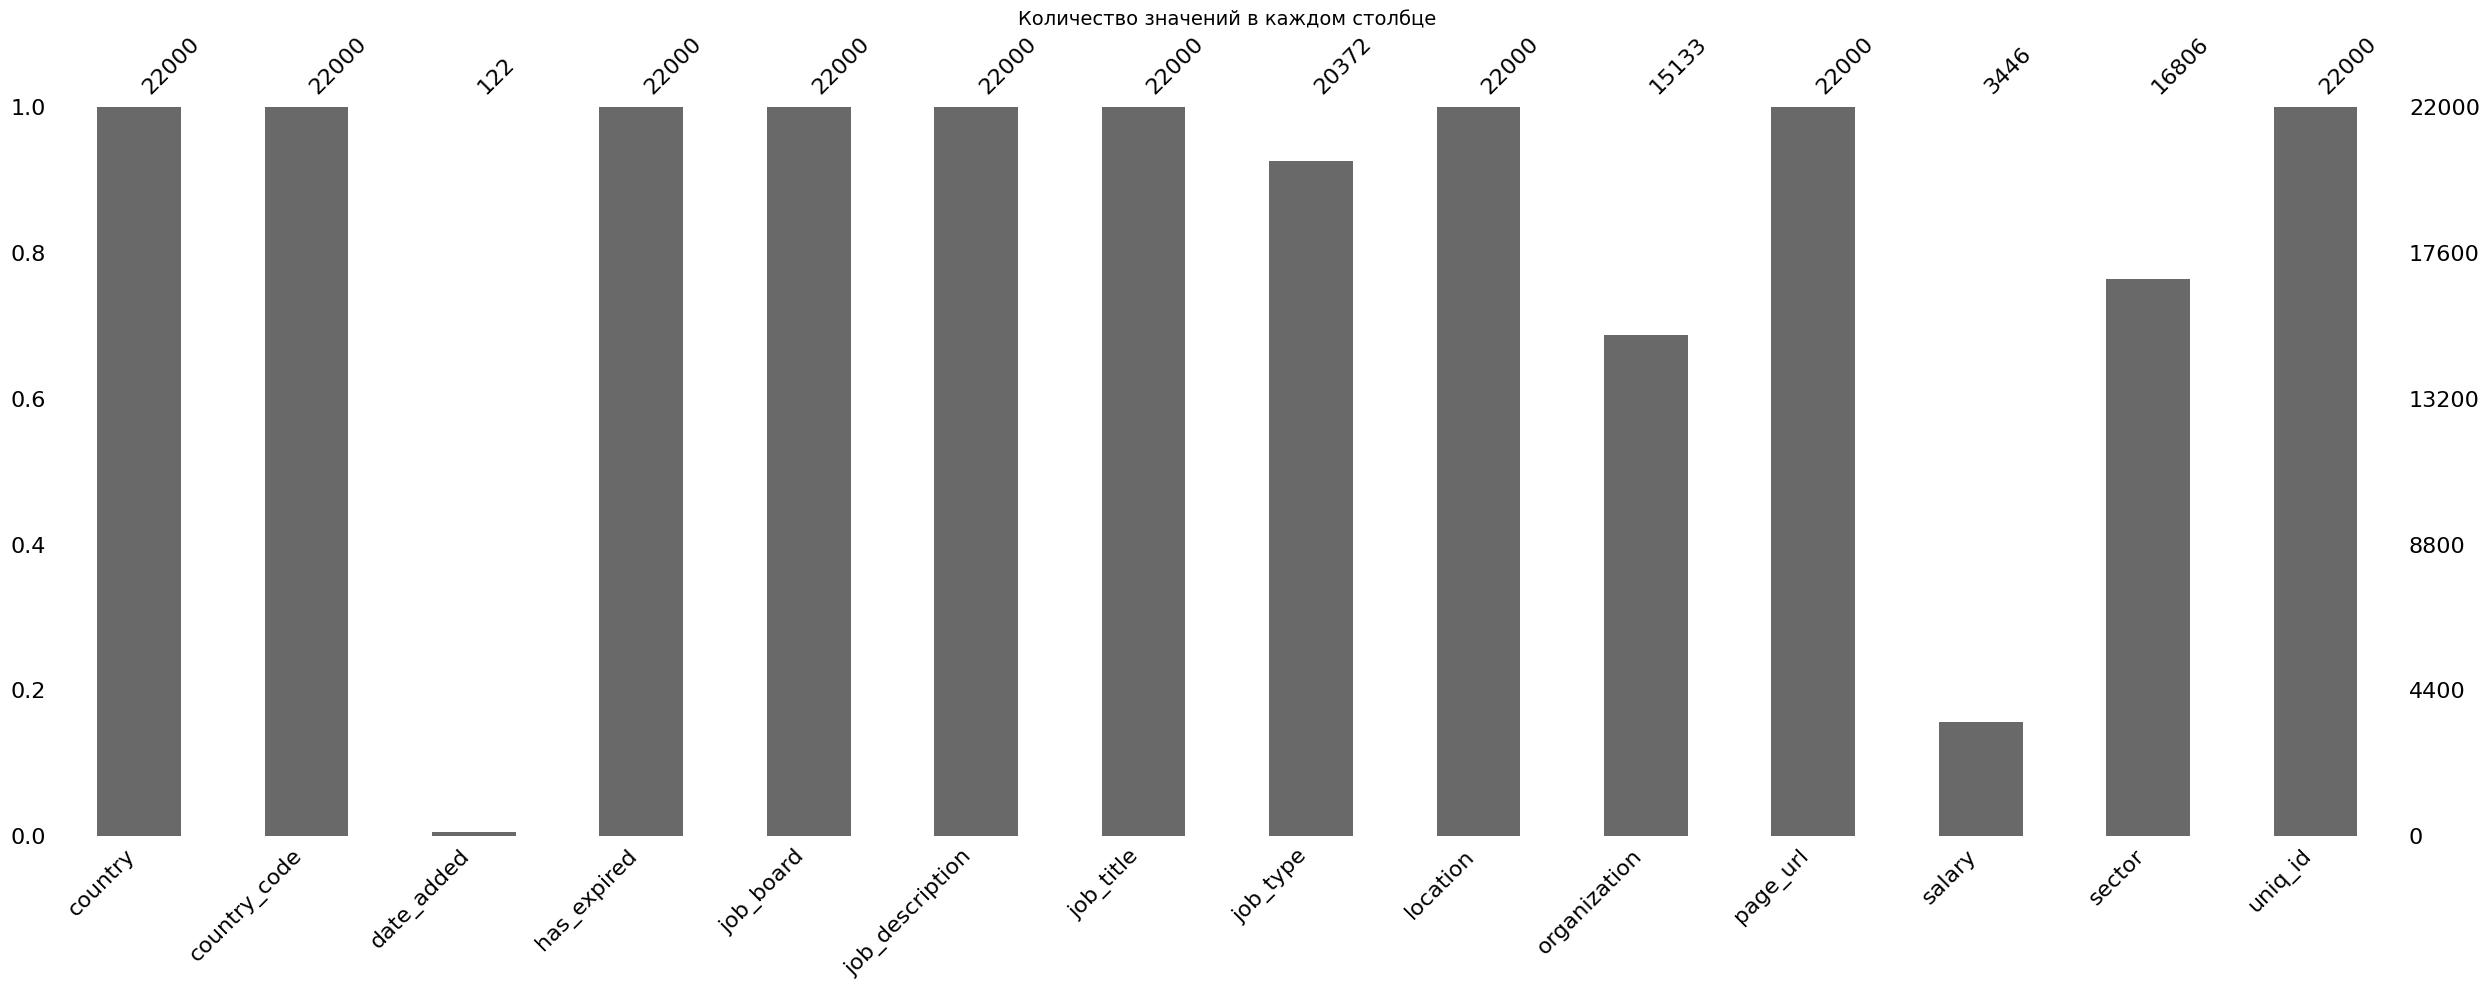

In [8]:
missing_stats = pd.DataFrame({
    'Всего_ячеек': len(df),
    'Пустые_ячееки': df.isnull().sum(),
    'Заполненные_ячейки': df.notnull().sum(),
    'Процент_пустых': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_stats

# у строк date_added и salary более 75% пустых значений

print("\nСтолбчатая диаграмма пропусков (missingno):")
plt.figure(figsize=(10, 6))
msno.bar(df)
plt.title('Количество значений в каждом столбце', fontsize=14)
plt.tight_layout()
plt.show()


Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

In [9]:
print(f"Исходный размер датасета: {df.shape}")
print(f"Исходное количество строк: {len(df)}")
print(f"Исходное количество столбцов: {len(df.columns)}")

df_no_missing = df.dropna()
print(f"\nПосле удаления ВСЕХ строк с пустыми значениями:")
print(f"Размер датасета: {df_no_missing.shape}")
print(f"Количество строк: {len(df_no_missing)}")
print(f"Потеряно строк: {len(df) - len(df_no_missing)}")
print(f"Процент потерянных данных: {(1 - len(df_no_missing) / len(df)) * 100:.2f}%")


Исходный размер датасета: (22000, 14)
Исходное количество строк: 22000
Исходное количество столбцов: 14

После удаления ВСЕХ строк с пустыми значениями:
Размер датасета: (5, 14)
Количество строк: 5
Потеряно строк: 21995
Процент потерянных данных: 99.98%


### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца?

In [10]:
single_value_columns = []
#Задание 1
for column in df.columns:
    unique_values = df[column].nunique()
    if unique_values == 1:
        single_value_columns.append(column)
        unique_val = df[column].iloc[0]
        print(f"{column}: только одно значение '{unique_val}'")
    elif unique_values <= 5:
        print(f"{column}: {unique_values} уникальных значений - {df[column].unique()}")

# эти столбцы можно удалить их анализа, так как они не несут информации

#Задание 2
column_pairs = []
for i, col1 in enumerate(df.columns):
    for j, col2 in enumerate(df.columns):
        if i < j and df[col1].dtype == 'object' and df[col2].dtype == 'object':
            # проверяем, насколько значения похожи
            sample_size = min(100, len(df))
            sample1 = df[col1].dropna().head(sample_size)
            sample2 = df[col2].dropna().head(sample_size)

            if len(sample1) > 0 and len(sample2) > 0:
                # проверяем пересечение значений
                common_values = set(sample1) & set(sample2)
                if len(common_values) > 0:
                    column_pairs.append((col1, col2, len(common_values), common_values))

# сортируем по количеству общих значений
column_pairs.sort(key=lambda x: x[2], reverse=True)

if column_pairs:
    print("Найдены столбцы с общими значениями:")
    for col1, col2, count, values in column_pairs[:10]:  # Показываем топ-10
        print(f"  {col1} = {col2}: {count} общих значений")
        if count <= 3:
            print(f" примеры: {list(values)[:3]}")
else:
    print("дублирований не обнаружено")

#Задание 3

problems_found = []
if 'date_added' in df.columns:
    date_sample = df['date_added'].dropna().head(5)
    if any(not pd.to_datetime(date, errors='coerce') for date in date_sample if date):
        problems_found.append("date_added: некорректный формат дат")

if 'page_url' in df.columns:
    url_sample = df['page_url'].dropna().head(5)
    if any(not str(url).startswith('http') for url in url_sample):
        problems_found.append("page_url: некорректные ссылки")

if 'salary' in df.columns:
    salary_sample = df['salary'].dropna().head(5)
    if all(not any(c.isdigit() for c in str(sal)) for sal in salary_sample):
        problems_found.append("salary: нет числовых значений")

if 'has_expired' in df.columns:
    expired_values = df['has_expired'].unique()
    if not all(str(val).lower() in ['yes', 'no', 'true', 'false'] for val in expired_values if pd.notnull(val)):
        problems_found.append("has_expired: нелогические значения")

if problems_found:
    print("Найдены несоответствия:")
    for problem in problems_found:
        print(f"{problem}")
else:
    print("все данные соответствуют названиям столбцов")

country: только одно значение 'United States of America'
country_code: только одно значение 'US'
has_expired: только одно значение 'No'
job_board: только одно значение 'jobs.monster.com'
Найдены столбцы с общими значениями:
  job_description = location: 1 общих значений
 примеры: ["Respiratory Therapist PRN Nights - Kindred Hospital Medical Center ( Job Number: 266123 ) Description IT'S SIMPLE. You want to work in a healthcare setting where you are valued and appreciated - where you receive respect from your superiors and co-workers as well as the patients you treat. You want to be challenged by your job without being overwhelmed by it. You want to play an instrumental role in helping a patient recover, sometimes against strong odds, and go home. What you want is Kindred Healthcare. Our mission is to promote healing, provide hope, preserve dignity and produce value for each patient, resident, family member, customer, employee and shareholder we serve. Join us! Summary: The Respiratory 

### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [11]:
#1
unique_ids_count = df['uniq_id'].nunique()
total_rows = len(df)
if unique_ids_count == total_rows:
    print("все uniq_id уникальны")
else:
    duplicates = total_rows - unique_ids_count
    print(f"найдено {duplicates} дубликатов id")

#2
unique_columns = []
for column in df.columns:
    if column != 'uniq_id':
        unique_count = df[column].nunique()
        if unique_count == total_rows:
            unique_columns.append(column)
            print(f"{column}: все значения различные")

#3
columns_to_check = [col for col in df.columns if col not in ['uniq_id'] + unique_columns]

# ищу полные дубликаты
duplicate_rows = df[df.duplicated(columns_to_check, keep=False)]
duplicate_count = len(duplicate_rows) - duplicate_rows.drop_duplicates(columns_to_check).shape[0]

if duplicate_count > 0:
    print(f"найдено {duplicate_count} дубликатов строк")
    print(f"уникальных комбинаций: {df[columns_to_check].drop_duplicates().shape[0]}")

    # примеры дубликатов
    duplicate_groups = duplicate_rows.groupby(columns_to_check).size().reset_index(name='count')
    duplicate_groups = duplicate_groups[duplicate_groups['count'] > 1]
    duplicate_groups.head(3)
else:
    print("дубликатов строк не найдено")


все uniq_id уникальны
page_url: все значения различные
найдено 1168 дубликатов строк
уникальных комбинаций: 20832


# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

1. Встречающиеся форматы location:
city_state_zip: 11409 записей (51.9%)
city_state: 7611 записей (34.6%)
state_only: 729 записей (3.3%)
city_only: 713 записей (3.2%)
zip_only: 594 записей (2.7%)
unknown: 472 записей (2.1%)
state_zip: 464 записей (2.1%)
city_zip: 8 записей (0.0%)


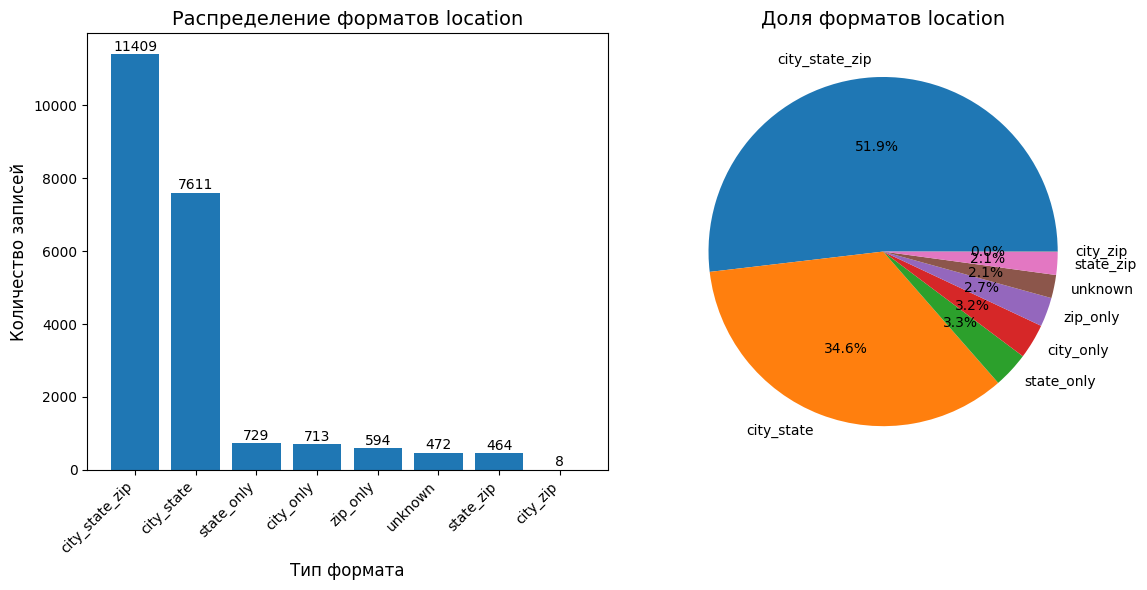

In [12]:
import re
patterns = {
    'city': r'^[A-Za-z\s\.]+(?=,|\s*$)',  # название города (до запятой или конца строки)
    'state_code': r'\b[A-Z]{2}\b',  # код штата (2 заглавные буквы)
    'zip_code': r'\b\d{5}(?:-\d{4})?\b',  # почтовый индекс (5 или 9 цифр)
    'comma_separated': r'.+,.+'  # наличие запятой как разделителя
}
def analyze_location_format(location):
    """Анализирует формат location и возвращает тип формата"""
    if pd.isna(location) or location == "":
        return "empty"
    location_str = str(location).strip()
    # Проверяем
    has_city = bool(re.search(patterns['city'], location_str))
    has_state = bool(re.search(patterns['state_code'], location_str))
    has_zip = bool(re.search(patterns['zip_code'], location_str))
    has_comma = bool(re.search(patterns['comma_separated'], location_str))

    # Определяем тип формата
    if has_city and has_state and has_zip:
        return "city_state_zip"
    elif has_city and has_state:
        return "city_state"
    elif has_city and has_zip:
        return "city_zip"
    elif has_state and has_zip:
        return "state_zip"
    elif has_city:
        return "city_only"
    elif has_state:
        return "state_only"
    elif has_zip:
        return "zip_only"
    else:
        return "unknown"

# Применяем анализ ко всем location
location_formats = df['location'].apply(analyze_location_format)
format_counts = location_formats.value_counts()

print("1. Встречающиеся форматы location:")
for format_type, count in format_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{format_type}: {count} записей ({percentage:.1f}%)")

#визуализация
plt.figure(figsize=(12, 6))
# Столбчатая диаграмма
plt.subplot(1, 2, 1)
bars = plt.bar(format_counts.index, format_counts.values)
plt.title('Распределение форматов location', fontsize=14)
plt.xlabel('Тип формата', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Добавляем значения на столбцы
for bar, value in zip(bars, format_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(value), ha='center', va='bottom')

# Круговая диаграмма
plt.subplot(1, 2, 2)
plt.pie(format_counts.values, labels=format_counts.index, autopct='%1.1f%%')
plt.title('Доля форматов location', fontsize=14)

plt.tight_layout()
plt.show()


#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, преобразуйте их в целочисленный формат.

In [24]:
# Создаем копию датафрейма
df_processed = df.copy()

# Определяем patterns для анализа location
patterns = {
    'city': r'[A-Za-z\s\.\-]+',  # Название города
    'state_code': r'\b[A-Z]{2}\b',  # Код штата (2 заглавные буквы)
    'zip_code': r'\b\d{5}(?:-\d{4})?\b',  # Почтовый индекс
    'comma_separated': r'.+,.+'  # Наличие запятой как разделителя
}

# Функция для анализа формата location
def analyze_location_format(location):
    """Анализирует формат location и возвращает тип формата"""
    if pd.isna(location) or location == "":
        return "empty"
    location_str = str(location).strip()
    # Проверяем компоненты
    has_city = bool(re.search(patterns['city'], location_str))
    has_state = bool(re.search(patterns['state_code'], location_str))
    has_zip = bool(re.search(patterns['zip_code'], location_str))
    has_comma = bool(re.search(patterns['comma_separated'], location_str))

    # Определяем тип формата
    if has_city and has_state and has_zip:
        return "city_state_zip"
    elif has_city and has_state:
        return "city_state"
    elif has_city and has_zip:
        return "city_zip"
    elif has_state and has_zip:
        return "state_zip"
    elif has_city:
        return "city_only"
    elif has_state:
        return "state_only"
    elif has_zip:
        return "zip_only"
    else:
        return "unknown"

# Функция для очистки ZIP кода
def clean_zip_code(zip_str):
    """Очищает и преобразует ZIP код в целое число"""
    if pd.isna(zip_str):
        return None
    # Убираем возможные дефисы и пробелы, берем только первые 5 цифр
    clean_zip = re.sub(r'[^\d]', '', str(zip_str))[:5]
    return int(clean_zip) if clean_zip.isdigit() and len(clean_zip) == 5 else None

# Функция для извлечения конкретных компонентов
def extract_location_components(location):
    """Извлекает город, штат и ZIP из location"""
    if pd.isna(location) or location == "":
        return None, None, None

    location_str = str(location).strip()
    city = None
    state = None
    zip_code = None

    # извлекаем штат
    state_match = re.search(patterns['state_code'], location_str)
    if state_match:
        state = state_match.group()

    # извлекаем ZIP код
    zip_match = re.search(patterns['zip_code'], location_str)
    if zip_match:
        zip_code = zip_match.group()

    # извлекаем город (все, что не штат и не ZIP)
    if state or zip_code:
        temp_str = location_str
        if state:
            temp_str = temp_str.replace(state, '')
        if zip_code:
            temp_str = temp_str.replace(zip_code, '')
        # убираем лишние запятые и пробелы
        temp_str = re.sub(r'^\s*,\s*|\s*,\s*$', '', temp_str).strip()
        if temp_str and re.search(patterns['city'], temp_str):
            city = temp_str
    else:
        # Если нет штата и ZIP, пробуем взять весь текст как город
        city_match = re.search(patterns['city'], location_str)
        if city_match:
            city = city_match.group().strip()

    return city, state, zip_code

# применяем анализ к location
df_processed['location_format'] = df_processed['location'].apply(analyze_location_format)

# извлекаем компоненты
location_components = df_processed['location'].apply(extract_location_components)
df_processed['city'] = [comp[0] for comp in location_components]
df_processed['state_code'] = [comp[1] for comp in location_components]
df_processed['zip_code'] = [comp[2] for comp in location_components]

# Создаем столбец zip_code_int
df_processed['zip_code_int'] = df_processed['zip_code'].apply(clean_zip_code)
print(f"Преобразовано ZIP кодов: {df_processed['zip_code_int'].notna().sum()}")

# Теперь можно создавать sample
sample_known = df_processed[['location', 'city', 'state_code', 'zip_code_int', 'location_format']].head(10)
sample_known

Преобразовано ZIP кодов: 12475


,location,city,state_code,zip_code_int,location_format
0,"Madison, WI 53702",Madison,WI,53702.0,city_state_zip
1,"Madison, WI 53708",Madison,WI,53708.0,city_state_zip
2,DePuy Synthes Companies is a member of Johnson...,DePuy Synthes Companies is a member of Johnson...,MA,NaN,city_state
3,"Dixon, CA",Dixon,CA,NaN,city_state
4,"Camphill, PA",Camphill,PA,NaN,city_state
5,"Charlottesville, VA",Charlottesville,VA,NaN,city_state
6,Contact name Tony Zerio,Contact name Tony Zerio,None,NaN,city_only
7,"Austin, TX 73301",Austin,TX,73301.0,city_state_zip
8,"Austin, TX 78746",Austin,TX,78746.0,city_state_zip
9,"Chesterfield, MO",Chesterfield,MO,NaN,city_state


Рассмотрите отложенную часть выборки (ту, где не удалось
данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

In [25]:
# 1. Выносим в отдельный датасет записи с неизвестным форматом
unknown_format_mask = df_processed['location_format'] == 'unknown'
df_unknown = df_processed[unknown_format_mask].copy()
df_known = df_processed[~unknown_format_mask].copy()

print(f"Успешно обработано: {len(df_known)} записей")
print(f"Неизвестный формат: {len(df_unknown)} записей")


# результаты для известных форматов
print("Примеры успешно обработанных записей:")
sample_known = df_known[['location', 'city', 'state_code', 'zip_code_int', 'location_format']].head(10)
print(sample_known)

# 3. Обработка неизвестных форматов

if len(df_unknown) > 0:
    # Пробуем извлечь данные из неизвестных форматов
    unknown_components = df_unknown['location'].apply(extract_location_components)
    df_unknown['city_extracted'] = [comp[0] for comp in unknown_components]
    df_unknown['state_code_extracted'] = [comp[1] for comp in unknown_components]
    df_unknown['zip_code_extracted'] = [comp[2] for comp in unknown_components]

    # Преобразуем извлеченные ZIP коды
    df_unknown['zip_code_int_extracted'] = df_unknown['zip_code_extracted'].apply(clean_zip_code)

    print(f"Из неизвестных форматов удалось извлечь:")
    print(f"  - Города: {df_unknown['city_extracted'].notna().sum()}")
    print(f"  - Коды штатов: {df_unknown['state_code_extracted'].notna().sum()}")
    print(f"  - ZIP коды: {df_unknown['zip_code_int_extracted'].notna().sum()}")

    # Покажем примеры извлечения из неизвестных форматов
    print("\nПримеры извлечения из неизвестных форматов:")
    sample_unknown = df_unknown[['location', 'city_extracted', 'state_code_extracted', 'zip_code_int_extracted']].head(5)
    print(sample_unknown)
else:
    print("Неизвестных форматов не найдено")


Успешно обработано: 22000 записей
Неизвестный формат: 0 записей
Примеры успешно обработанных записей:
                                            location  \
0                                  Madison, WI 53702   
1                                  Madison, WI 53708   
2  DePuy Synthes Companies is a member of Johnson...   
3                                          Dixon, CA   
4                                       Camphill, PA   
5                                Charlottesville, VA   
6                            Contact name Tony Zerio   
7                                   Austin, TX 73301   
8                                   Austin, TX 78746   
9                                   Chesterfield, MO   

                                                city state_code  zip_code_int  \
0                                            Madison         WI       53702.0   
1                                            Madison         WI       53708.0   
2  DePuy Synthes Companies is a member

### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

1. ВСТРЕЧАЮЩИЕСЯ ФОРМАТЫ SALARY:
   empty: 18557 записей (84.4%)
   unknown: 2102 записей (9.6%)
   hourly_range: 1060 записей (4.8%)
   with_plus: 171 записей (0.8%)
   yearly_range: 70 записей (0.3%)
   yearly_single: 19 записей (0.1%)
   weekly_single: 11 записей (0.1%)
   only_numbers: 6 записей (0.0%)
   weekly_range: 3 записей (0.0%)
   hourly_single: 1 записей (0.0%)


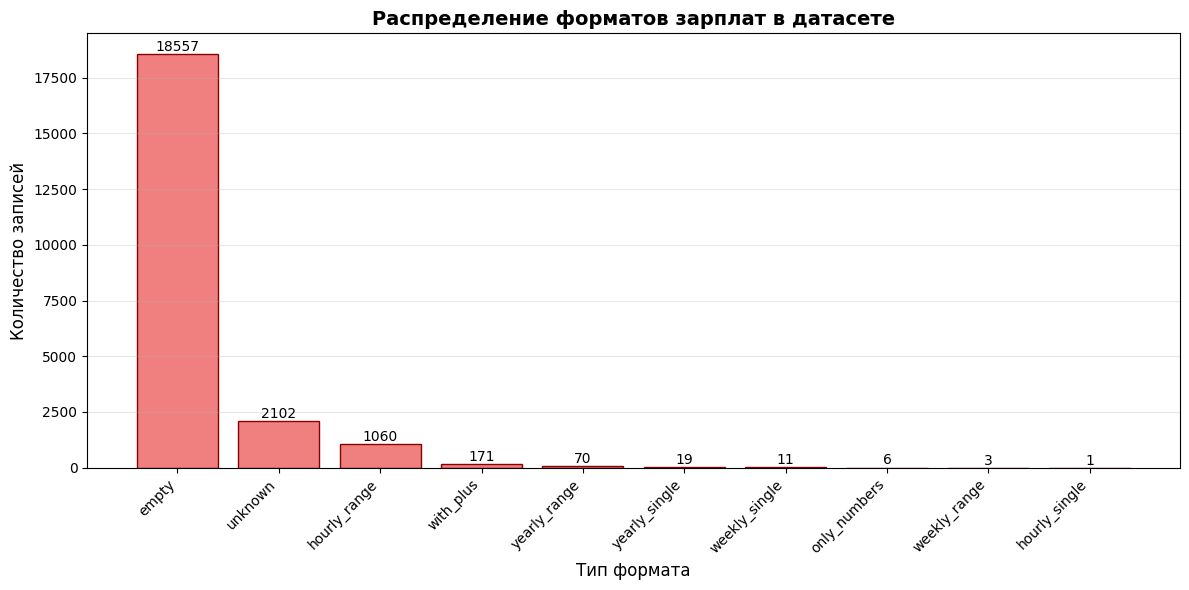

   - Заполненность столбца salary: 15.7%
   - Самый частый формат: empty
   - Неизвестных форматов: 2102


In [17]:
# Регулярные выражения для различных форматов зарплат
salary_patterns = {
    'hourly_range': r'\d+[,\.]?\d*\s*-\s*\d+[,\.]?\d*\s*\$?\s*\/?\s*hour',
    'yearly_range': r'\d+[,\.]?\d*\s*-\s*\d+[,\.]?\d*\s*\$?\s*\/?\s*year',
    'monthly_range': r'\d+[,\.]?\d*\s*-\s*\d+[,\.]?\d*\s*\$?\s*\/?\s*month',
    'weekly_range': r'\d+[,\.]?\d*\s*-\s*\d+[,\.]?\d*\s*\$?\s*\/?\s*week',
    'hourly_single': r'\$?\s*\d+[,\.]?\d*\s*\/?\s*hour',
    'yearly_single': r'\$?\s*\d+[,\.]?\d*\s*\/?\s*year',
    'monthly_single': r'\$?\s*\d+[,\.]?\d*\s*\/?\s*month',
    'weekly_single': r'\$?\s*\d+[,\.]?\d*\s*\/?\s*week',
    'with_plus': r'\d+[,\.]?\d*\s*\+\s*\/?\s*(?:hour|year|month|week)',
    'upto': r'up to\s+\$?\s*\d+[,\.]?\d*\s*\/?\s*(?:hour|year|month|week)',
    'only_numbers': r'^\$?\s*\d+[,\.]?\d*\s*\$?$',
}

def analyze_salary_format(salary):
    """Анализирует формат salary и возвращает тип формата"""
    if pd.isna(salary) or str(salary).strip() == "":
        return "empty"

    salary_str = str(salary).strip().lower()

    # Проверяем каждый паттерн
    for format_name, pattern in salary_patterns.items():
        if re.search(pattern, salary_str, re.IGNORECASE):
            return format_name

    return "unknown"

# Анализируем форматы зарплат
salary_formats = df['salary'].apply(analyze_salary_format)
format_counts = salary_formats.value_counts()

print("1. ВСТРЕЧАЮЩИЕСЯ ФОРМАТЫ SALARY:")
for format_type, count in format_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {format_type}: {count} записей ({percentage:.1f}%)")

# 2. Визуализация
plt.figure(figsize=(12, 6))
bars = plt.bar(format_counts.index, format_counts.values, color='lightcoral', edgecolor='darkred')
plt.title('Распределение форматов зарплат в датасете', fontsize=14, fontweight='bold')
plt.xlabel('Тип формата', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, format_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#ВЫВОДЫ
print(f"   - Заполненность столбца salary: {(len(df) - format_counts.get('empty', 0)) / len(df) * 100:.1f}%")
print(f"   - Самый частый формат: {format_counts.index[0] if len(format_counts) > 0 else 'N/A'}")
print(f"   - Неизвестных форматов: {format_counts.get('unknown', 0)}")


#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

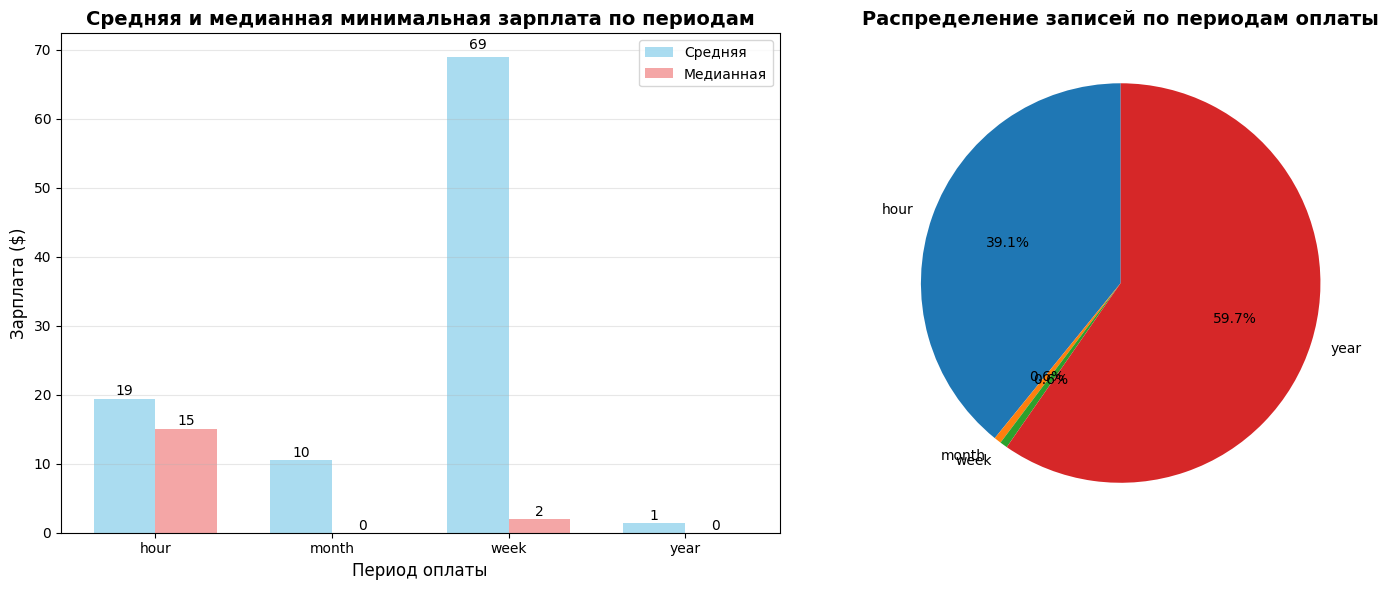

In [18]:
def extract_salary_components(salary):
    """Извлекает минимальную, максимальную зарплату и период из строки"""
    if pd.isna(salary) or str(salary).strip() == "":
        return None, None, None

    salary_str = str(salary).strip().lower()

    # Определяем период
    period = None
    for p in ['hour', 'year', 'month', 'week']:
        if p in salary_str:
            period = p
            break

    # Извлекаем все числовые значения
    numbers = re.findall(r'\d+[,\.]?\d*', salary_str)

    # Очищаем и преобразуем числа
    clean_numbers = []
    for num in numbers:
        # Заменяем запятые на точки для тысяч и убираем лишние символы
        clean_num = num.replace(',', '')
        try:
            clean_numbers.append(float(clean_num))
        except ValueError:
            continue

    min_salary = None
    max_salary = None

    if len(clean_numbers) >= 2:
        # Диапазон зарплат
        min_salary = min(clean_numbers)
        max_salary = max(clean_numbers)
    elif len(clean_numbers) == 1:
        # Одна зарплата
        min_salary = clean_numbers[0]
        max_salary = clean_numbers[0]

    return min_salary, max_salary, period

# Применяем функцию ко всем зарплатам
salary_components = df['salary'].apply(extract_salary_components)

# Создаем новые столбцы
df['min_salary'] = [comp[0] for comp in salary_components]
df['max_salary'] = [comp[1] for comp in salary_components]
df['salary_period'] = [comp[2] for comp in salary_components]

# 2. Визуализация

# Фильтруем данные с известным периодом и зарплатой
salary_data = df[(df['salary_period'].notna()) & (df['min_salary'].notna())].copy()

if len(salary_data) > 0:
    # Группируем по периоду и вычисляем статистики
    period_stats = salary_data.groupby('salary_period')['min_salary'].agg(['mean', 'median', 'count']).round(2)
        # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Столбчатая диаграмма с группировкой
    periods = period_stats.index
    x = np.arange(len(periods))
    width = 0.35

    bars1 = ax1.bar(x - width/2, period_stats['mean'], width, label='Средняя', alpha=0.7, color='skyblue')
    bars2 = ax1.bar(x + width/2, period_stats['median'], width, label='Медианная', alpha=0.7, color='lightcoral')

    ax1.set_xlabel('Период оплаты', fontsize=12)
    ax1.set_ylabel('Зарплата ($)', fontsize=12)
    ax1.set_title('Средняя и медианная минимальная зарплата по периодам', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(periods)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:.0f}', ha='center', va='bottom', fontsize=10)

    # Круговая диаграмма распределения периодов
    ax2.pie(period_stats['count'], labels=period_stats.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Распределение записей по периодам оплаты', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()


#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

hour:
Записей: 1149
Диапазон: $0.00 - $100.00
Среднее: $19.32
Стандартное отклонение: $13.76
year:
Записей: 1751
Диапазон: $0.00 - $750.00
Среднее: $1.44
Стандартное отклонение: $18.99
week:
Записей: 18
Диапазон: $0.00 - $600.00
Среднее: $68.94
Стандартное отклонение: $193.22
month:
Записей: 17
Диапазон: $0.00 - $66.00
Среднее: $10.47
Стандартное отклонение: $19.13

2. ГИСТОГРАММЫ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ ПО ПЕРИОДАМ:


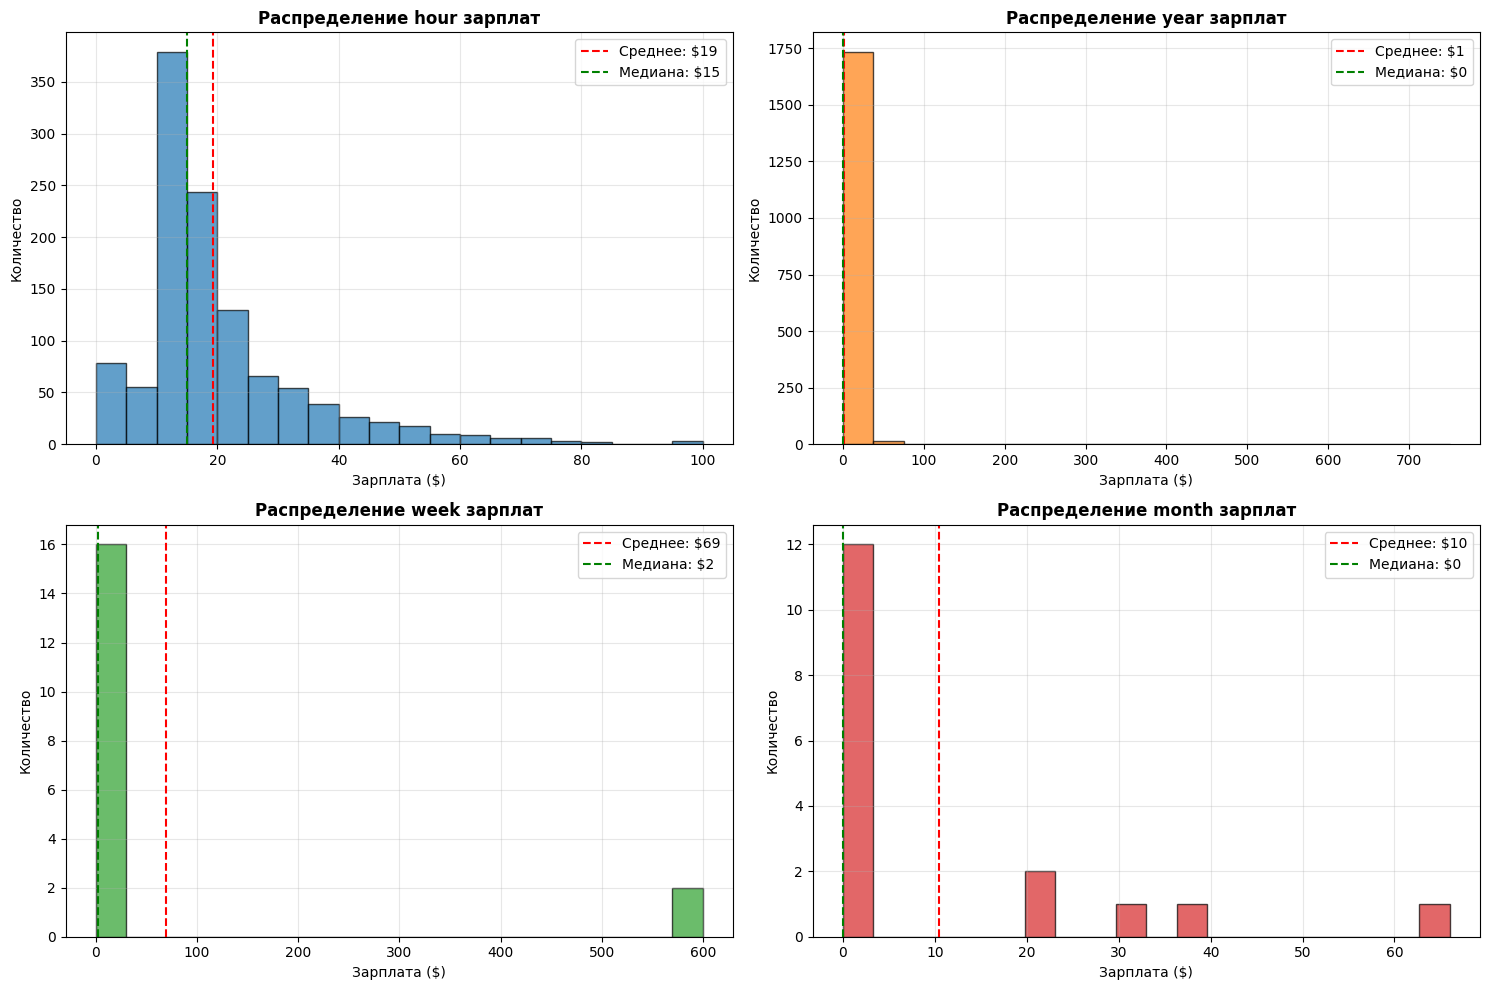


3. ВОССТАНОВЛЕНИЕ ПЕРИОДОВ ДЛЯ ЗАРПЛАТ БЕЗ УКАЗАНИЯ:
Найдено записей без периода: 150

5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ВОССТАНОВЛЕНИЯ:


/tmp/ipython-input-3196403476.py:127: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(plot_data, labels=labels)


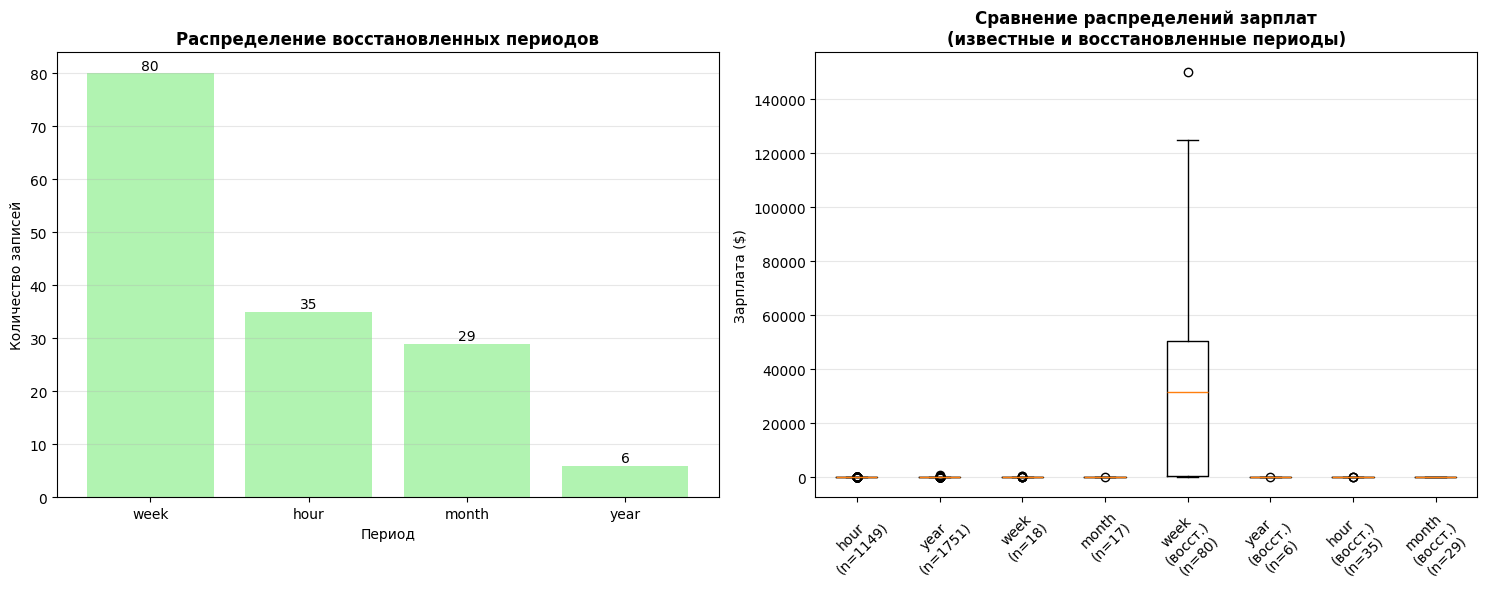

In [19]:
# Фильтруем данные с известным периодом
known_period_data = df[(df['salary_period'].notna()) & (df['min_salary'].notna())].copy()

period_ranges = {}
for period in known_period_data['salary_period'].unique():
    period_data = known_period_data[known_period_data['salary_period'] == period]['min_salary']
    period_ranges[period] = {
        'min': period_data.min(),
        'max': period_data.max(),
        'mean': period_data.mean(),
        'std': period_data.std(),
        'count': len(period_data)
    }
    print(f"{period}:")
    print(f"Записей: {period_ranges[period]['count']}")
    print(f"Диапазон: ${period_ranges[period]['min']:.2f} - ${period_ranges[period]['max']:.2f}")
    print(f"Среднее: ${period_ranges[period]['mean']:.2f}")
    print(f"Стандартное отклонение: ${period_ranges[period]['std']:.2f}")

# 2. Построение гистограмм для каждого периода
print("\n2. ГИСТОГРАММЫ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ ПО ПЕРИОДАМ:")

if len(known_period_data) > 0:
    periods = known_period_data['salary_period'].unique()
    n_periods = len(periods)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, period in enumerate(periods):
        if i < len(axes):
            period_salaries = known_period_data[known_period_data['salary_period'] == period]['min_salary']

            axes[i].hist(period_salaries, bins=20, alpha=0.7, color=f'C{i}', edgecolor='black')
            axes[i].set_title(f'Распределение {period} зарплат', fontweight='bold')
            axes[i].set_xlabel('Зарплата ($)')
            axes[i].set_ylabel('Количество')
            axes[i].grid(alpha=0.3)

            # Добавляем вертикальные линии для статистик
            mean_val = period_salaries.mean()
            median_val = period_salaries.median()
            axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: ${mean_val:.0f}')
            axes[i].axvline(median_val, color='green', linestyle='--', label=f'Медиана: ${median_val:.0f}')
            axes[i].legend()

    # Скрываем пустые subplots
    for i in range(n_periods, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

# 3. Определение периодов для зарплат без указания периода
print("\n3. ВОССТАНОВЛЕНИЕ ПЕРИОДОВ ДЛЯ ЗАРПЛАТ БЕЗ УКАЗАНИЯ:")

# Находим записи без периода но с зарплатой
unknown_period_data = df[(df['salary_period'].isna()) & (df['min_salary'].notna())].copy()

print(f"Найдено записей без периода: {len(unknown_period_data)}")

def find_closest_period(salary, period_ranges):
    """Определяет ближайший период для зарплаты"""
    if not period_ranges:
        return None

    distances = {}
    for period, stats in period_ranges.items():
        # Используем расстояние до среднего значения
        distance = abs(salary - stats['mean'])
        distances[period] = distance

    # Находим минимальное расстояние
    min_distance = min(distances.values())

    # Проверяем, нет ли нескольких периодов с одинаковым расстоянием
    closest_periods = [p for p, d in distances.items() if d == min_distance]

    # Если только один ближайший период - возвращаем его
    if len(closest_periods) == 1:
        return closest_periods[0]
    else:
        # В спорных случаях не выбираем ничего
        return None

# Применяем функцию к данным без периода
unknown_period_data['predicted_period'] = unknown_period_data['min_salary'].apply(
    lambda x: find_closest_period(x, period_ranges)
)

# 5. Визуализация результатов
print("\n5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ВОССТАНОВЛЕНИЯ:")

if len(unknown_period_data) > 0 and unknown_period_data['predicted_period'].notna().sum() > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Столбчатая диаграмма восстановленных периодов
    predicted_data = unknown_period_data[unknown_period_data['predicted_period'].notna()]
    predicted_period_counts = predicted_data['predicted_period'].value_counts()

    ax1.bar(predicted_period_counts.index, predicted_period_counts.values, color='lightgreen', alpha=0.7)
    ax1.set_title('Распределение восстановленных периодов', fontweight='bold')
    ax1.set_xlabel('Период')
    ax1.set_ylabel('Количество записей')
    ax1.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for i, (period, count) in enumerate(predicted_period_counts.items()):
        ax1.text(i, count + 0.1, str(count), ha='center', va='bottom')

    # Boxplot сравнения распределений
    plot_data = []
    labels = []

    # Добавляем известные периоды
    for period in known_period_data['salary_period'].unique():
        period_salaries = known_period_data[known_period_data['salary_period'] == period]['min_salary']
        plot_data.append(period_salaries)
        labels.append(f'{period}\n(n={len(period_salaries)})')

    # Добавляем восстановленные периоды
    for period in predicted_data['predicted_period'].unique():
        period_salaries = predicted_data[predicted_data['predicted_period'] == period]['min_salary']
        plot_data.append(period_salaries)
        labels.append(f'{period}\n(восст.)\n(n={len(period_salaries)})')

    ax2.boxplot(plot_data, labels=labels)
    ax2.set_title('Сравнение распределений зарплат\n(известные и восстановленные периоды)', fontweight='bold')
    ax2.set_ylabel('Зарплата ($)')
    ax2.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

БАЗОВАЯ СТАТИСТИКА:
'Full Time': 6757 записей (30.7%)
'Full Time Employee': 6617 записей (30.1%)
'Full Time, Employee': 3360 записей (15.3%)
'Full Time Temporary/Contract/Project': 1062 записей (4.8%)
'Full Time, Temporary/Contract/Project': 533 записей (2.4%)
'Full Time , Employee': 406 записей (1.8%)
'Part Time Employee': 382 записей (1.7%)
'Part Time': 329 записей (1.5%)
'Part Time, Employee': 196 записей (0.9%)
'Temporary/Contract/Project': 193 записей (0.9%)
'Employee': 147 записей (0.7%)
'Full Time / Employee': 121 записей (0.5%)
'Full Time , Temporary/Contract/Project': 56 записей (0.3%)
'Part Time, Temporary/Contract/Project': 34 записей (0.2%)
'Per Diem, Employee': 29 записей (0.1%)
'Per Diem': 22 записей (0.1%)
'Job Type Full Time Employee': 19 записей (0.1%)
'Part Time Seasonal': 17 записей (0.1%)
'Part Time/ Temporary/Contract/Project': 16 записей (0.1%)
'Full Time ': 14 записей (0.1%)
'Full Time/ Employee': 13 записей (0.1%)
'Per Diem Employee': 12 записей (0.1%)
'Part Tim

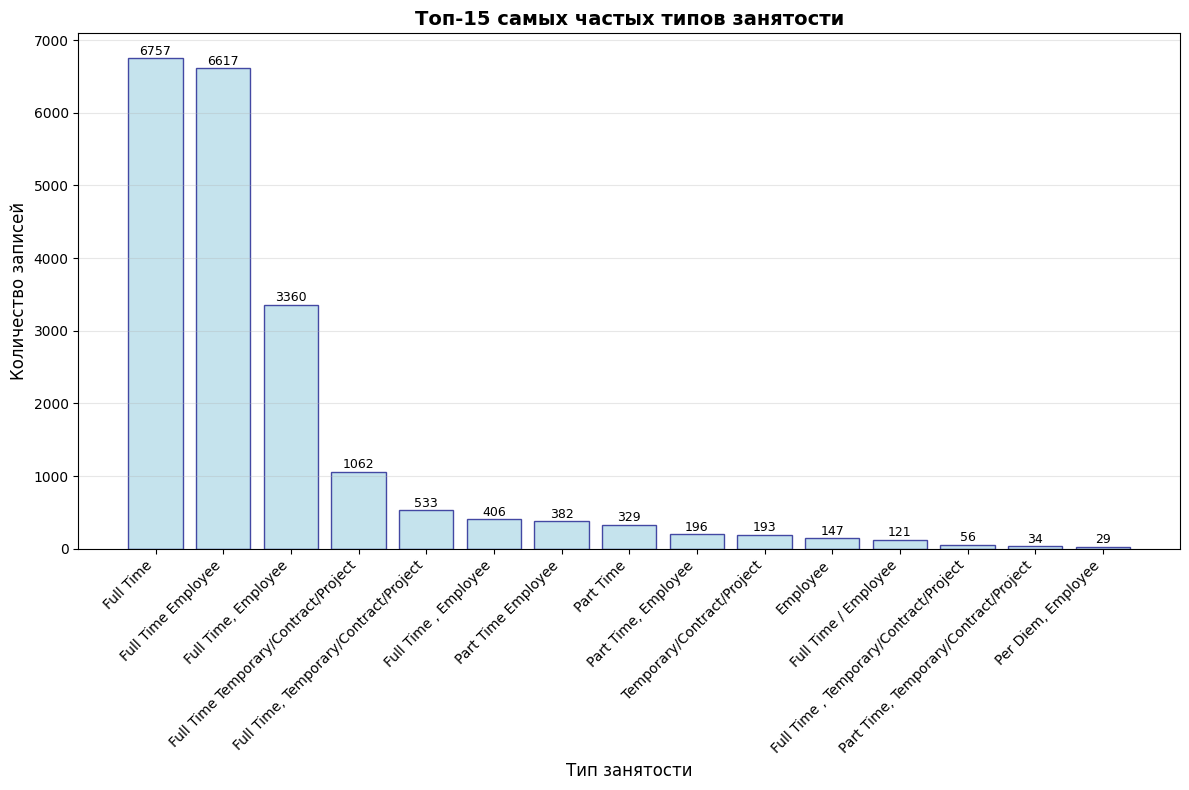

   Найдены потенциальные дубликаты:
     'full time' -> ['full time employee', 'full time, employee', 'full time temporary/contract/project', 'full time, temporary/contract/project', 'full time , employee', 'part time employee', 'part time', 'full time / employee', 'full time , temporary/contract/project', 'job type full time employee', 'part time seasonal', 'full time\xa0', 'full time/ employee', 'part time temporary/contract/project', 'full time intern', 'part time , employee', 'part time intern', 'job type full time', 'part time / employee', 'job type part time employee', 'job type full time temporary/contract/project', 'part time , temporary/contract/project', 'full time\xa0 employee', 'full time / temporary/contract/project', 'part time\xa0', 'full time / > employee']
     'full time employee' -> ['full time', 'full time, employee', 'full time temporary/contract/project', 'full time, temporary/contract/project', 'full time , employee', 'part time employee', 'part time', 'part time

In [20]:
# 1. Базовая статистика по столбцу job_type
print("БАЗОВАЯ СТАТИСТИКА:")
len(df)
df['job_type'].notna().sum()
df['job_type'].isna().sum()
df['job_type'].nunique()

# 2. Анализ уникальных значений
job_type_counts = df['job_type'].value_counts()
for job_type, count in job_type_counts.items():
    if pd.notna(job_type):
        percentage = (count / len(df)) * 100
        print(f"'{job_type}': {count} записей ({percentage:.1f}%)")

# 3. Визуализация
# Столбчатая диаграмма
plt.figure(figsize=(12, 8))
top_job_types = job_type_counts.head(15)

bars = plt.bar(range(len(top_job_types)), top_job_types.values, color='lightblue', edgecolor='navy', alpha=0.7)
plt.title('Топ-15 самых частых типов занятости', fontsize=14, fontweight='bold')
plt.xlabel('Тип занятости', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.xticks(range(len(top_job_types)), top_job_types.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, count in zip(bars, top_job_types.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Анализ проблем
# Поиск похожих значений (возможные дубликаты из-за разного написания)
job_types_lower = df['job_type'].str.lower().value_counts()
potential_duplicates = {}

for job_type in job_types_lower.index:
    if pd.notna(job_type):
        # Ищем похожие значения
        similar = []
        for other_type in job_types_lower.index:
            if pd.notna(other_type) and job_type != other_type:
                # Простая проверка схожести
                if job_type in other_type or other_type in job_type:
                    similar.append(other_type)
                elif len(set(job_type.split()) & set(other_type.split())) > 0:
                    similar.append(other_type)

        if similar:
            potential_duplicates[job_type] = similar

if potential_duplicates:
    print("   Найдены потенциальные дубликаты:")
    for main_type, similar_types in list(potential_duplicates.items())[:5]:  # Показываем первые 5
        print(f"     '{main_type}' -> {similar_types}")
else:
    print("   Потенциальные дубликаты не найдены")

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

In [21]:
standardization_map = {
    # Full-time
    'Full Time': 'Full-time',
    'Full-Time': 'Full-time',
    'FullTime': 'Full-time',
    'Full time': 'Full-time',
    'full-time': 'Full-time',
    'full time': 'Full-time',

    # Part-time
    'Part Time': 'Part-time',
    'Part-Time': 'Part-time',
    'PartTime': 'Part-time',
    'Part time': 'Part-time',
    'part-time': 'Part-time',
    'part time': 'Part-time',

    # Contract
    'Contractor': 'Contract',
    'Contract-to-Hire': 'Contract',
    'Contract to Hire': 'Contract',

    # Temporary
    'Temp': 'Temporary',
    'Temp-to-Hire': 'Temporary',

    # Internship
    'Intern': 'Internship',

    # Permanent
    'Permanent Employee': 'Permanent',

    # Volunteer
    'Volunteer Position': 'Volunteer',

    # Другие
    'Employee': 'Full-time',
    'Regular': 'Full-time',
}

#Функция для стандартизации
def standardize_job_type(job_type):
    if pd.isna(job_type):
        return job_type

    job_type_str = str(job_type).strip()

    # Проверяем точное совпадение в mapping
    if job_type_str in standardization_map:
        return standardization_map[job_type_str]

    # Проверяем частичные совпадения
    for key, value in standardization_map.items():
        if key.lower() in job_type_str.lower():
            return value

    # Если не нашли совпадений, возвращаем оригинальное значение (но с нормализацией пробелов)
    return ' '.join(job_type_str.split())

#Применяем стандартизацию
df['job_type_standardized'] = df['job_type'].apply(standardize_job_type)

Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

=== РАЗДЕЛЕНИЕ JOB_TYPE НА ПОЛНОТУ И ТИП ЗАНЯТОСТИ ===
   Распределение по полноте занятости:
Full Time: 20747 записей (94.3%)
Part Time: 993 записей (4.5%)
Contract: 193 записей (0.9%)
Per Diem: 67 записей (0.3%)

   Распределение по типу занятости:
Employee: 21992 записей (100.0%)
Intern: 8 записей (0.0%)


<Figure size 1200x800 with 0 Axes>

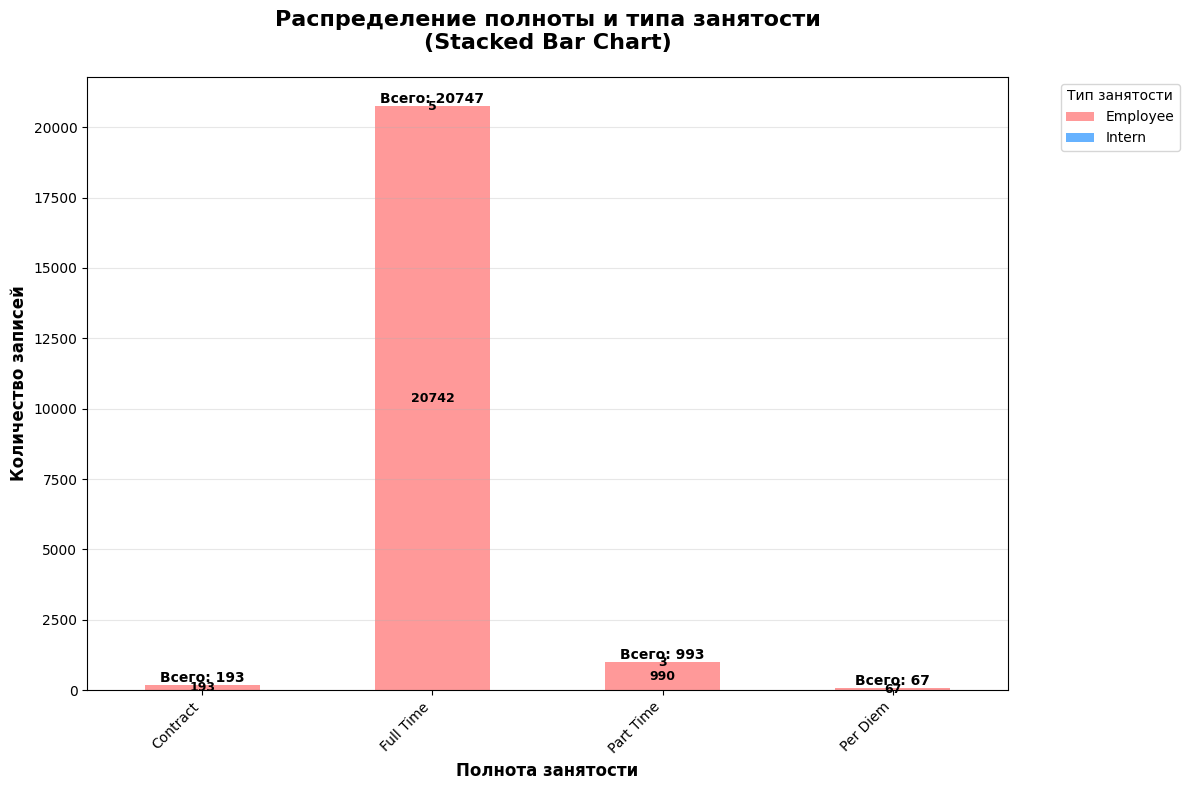

In [22]:
# Разделение столбца job_type на полноту и тип занятости
print("=== РАЗДЕЛЕНИЕ JOB_TYPE НА ПОЛНОТУ И ТИП ЗАНЯТОСТИ ===")

# 1. Регулярные выражения для разделения
employment_patterns = {
    'full_time': r'\b(?:full[\s-]?time|fulltime|ft)\b',
    'part_time': r'\b(?:part[\s-]?time|parttime|pt)\b',
    'per_diem': r'\b(?:per\s+diem|daily)\b',
    'contract': r'\b(?:contract|contractor|freelance)\b',
    'temporary': r'\b(?:temporary|temp|seasonal)\b'
}

employment_type_patterns = {
    'employee': r'\b(?:employee|staff|regular)\b',
    'intern': r'\b(?:intern|internship|trainee)\b',
    'volunteer': r'\b(?:volunteer|unpaid)\b',
    'contractor': r'\b(?:contractor|consultant|freelancer)\b'
}

def extract_employment_components(job_type):
    """Извлекает полноту и тип занятости из job_type"""
    if pd.isna(job_type):
        return "Full Time", "Employee"

    job_type_str = str(job_type).lower().strip()

    # Определяем полноту занятости
    employment_completeness = None
    for pattern_name, pattern in employment_patterns.items():
        if re.search(pattern, job_type_str, re.IGNORECASE):
            employment_completeness = pattern_name.replace('_', ' ').title()
            break

    # Определяем тип занятости
    employment_type = None
    for pattern_name, pattern in employment_type_patterns.items():
        if re.search(pattern, job_type_str, re.IGNORECASE):
            employment_type = pattern_name.title()
            break

    # Заполняем пропущенные значения по умолчанию
    if employment_completeness is None:
        employment_completeness = "Full Time"

    if employment_type is None:
        employment_type = "Employee"

    return employment_completeness, employment_type

#Применяем разделение к данным
employment_components = df['job_type'].apply(extract_employment_components)

# Создаем новые столбцы
df['employment_completeness'] = [comp[0] for comp in employment_components]
df['employment_type'] = [comp[1] for comp in employment_components]


completeness_counts = df['employment_completeness'].value_counts()
print("   Распределение по полноте занятости:")
for completeness, count in completeness_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{completeness}: {count} записей ({percentage:.1f}%)")

type_counts = df['employment_type'].value_counts()
print("\n   Распределение по типу занятости:")
for emp_type, count in type_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{emp_type}: {count} записей ({percentage:.1f}%)")

# Визуализация

cross_tab = pd.crosstab(df['employment_completeness'], df['employment_type'])

plt.figure(figsize=(12, 8))

# Стековая столбчатая диаграмма
ax = cross_tab.plot(kind='bar', stacked=True,
                   color=['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FF69B4'],
                   figsize=(12, 8))

plt.title('Распределение полноты и типа занятости\n(Stacked Bar Chart)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Полнота занятости', fontsize=12, fontweight='bold')
plt.ylabel('Количество записей', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип занятости', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (completeness, row) in enumerate(cross_tab.iterrows()):
    total = row.sum()
    current_height = 0
    for emp_type, count in row.items():
        if count > 0:
            ax.text(i, current_height + count/2, str(count),
                   ha='center', va='center', fontweight='bold', fontsize=9)
            current_height += count
    # Добавляем общее количество сверху
    ax.text(i, total + 5, f'Всего: {total}',
           ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.